# 01 · GBIF Image Collection

**Task**: Download training images for a binary deep-learning classifier that distinguishes
the invasive *Cortaderia selloana* (pampas grass) from the visually similar but non-invasive
*Miscanthus sinensis* (Chinese silver grass).

**Why these species?**
- *Cortaderia selloana* is one of Spain's most problematic invasive plants: it forms dense
  monocultures, displaces native vegetation, triggers allergic reactions, and is listed on
  Spain's national invasive-species catalogue.
- *Miscanthus sinensis* looks strikingly similar (same family, same silvery inflorescences),
  making visual identification hard for non-experts – exactly the kind of problem where a
  deep-learning model adds value.

**Output**
```
data/
  train/
    cortaderia_selloana/   (~320 images)
    miscanthus_sinensis/   (~320 images)
  val/
    cortaderia_selloana/   (~80 images)
    miscanthus_sinensis/   (~80 images)
```

In [1]:
# Install lightweight dependencies
%pip install -q requests Pillow tqdm pandas


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import json
import os
import random
import shutil
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import Manager
from io import BytesIO
from pathlib import Path

import pandas as pd
import requests
from PIL import Image
from tqdm.notebook import tqdm

from download_worker import download_species_worker

In [22]:
# ─── Configuration ────────────────────────────────────────────────────────────

def to_folder_name(s: str) -> str:
    return s.strip().lower().replace(" ", "_").replace("-", "_")

def gbif_species_match(scientific_name: str) -> int | None:
    """Resolve scientific name to GBIF usageKey (taxon_key) via API."""
    try:
        r = requests.get(
            "https://api.gbif.org/v1/species/match",
            params={"name": scientific_name.strip()},
            timeout=10,
        )
        r.raise_for_status()
        data = r.json()
        return data.get("usageKey") or data.get("speciesKey")
    except Exception:
        return None

SEED = 42
random.seed(SEED)

# Read species from 03_species_in_bbox output (run that notebook first!)
SPECIES_CSV = Path("species_for_training.csv")
df_species = pd.read_csv(SPECIES_CSV)
EXCLUDE = {"cortaderia_selloana", "miscanthus_sinensis"}  # already have data

# Top 5 invasive (by total_count), excluding cortaderia & miscanthus
inv = df_species[df_species["is_invasive"]].sort_values("total_count", ascending=False)
top_invasive = []
for _, row in inv.iterrows():
    fn = to_folder_name(row["scientificName"])
    if fn not in EXCLUDE and len(top_invasive) < 5:
        top_invasive.append(row)

# 5 random non-invasive species (sampling with SEED for reproducibility), excluding miscanthus
non_inv = df_species[~df_species["is_invasive"]]
non_inv = non_inv[non_inv["scientificName"].apply(to_folder_name) != "miscanthus_sinensis"]
non_inv_sample = non_inv.sample(n=min(5, len(non_inv)), random_state=SEED) if len(non_inv) > 0 else []

# Build SPECIES: invasive -> own folder; non-invasive -> all in "non_invasive" (one class)
SPECIES = {}
for row in top_invasive:
    sci = row["scientificName"]
    fn = to_folder_name(sci)
    taxon_key = row.get("speciesKey")
    if pd.isna(taxon_key) or taxon_key == "":
        taxon_key = gbif_species_match(sci)
    if taxon_key is None or (isinstance(taxon_key, float) and pd.isna(taxon_key)):
        print(f"  [SKIP] {sci}: no taxon_key")
        continue
    SPECIES[fn] = {"taxon_key": int(taxon_key), "display": f"{sci} – INVASIVE", "gbif_images_available": 0}

# Non-invasive: one folder, multiple species (for multiclass: one non-invasive class)
non_inv_taxon_keys = []
for _, row in non_inv_sample.iterrows():
    sci = row["scientificName"]
    taxon_key = row.get("speciesKey")
    if pd.isna(taxon_key) or taxon_key == "":
        taxon_key = gbif_species_match(sci)
    if taxon_key is not None and not (isinstance(taxon_key, float) and pd.isna(taxon_key)):
        non_inv_taxon_keys.append(int(taxon_key))
if non_inv_taxon_keys:
    SPECIES["non_invasive"] = {
        "taxon_key": non_inv_taxon_keys,  # list for multi-species
        "display": "non-invasive (multiple species)",
        "gbif_images_available": 0,
    }

TARGET_PER_CLASS = 300
VAL_RATIO       = 0.2
MIN_SIDE_PX     = 224
MAX_ASPECT      = 4.0
SHARPNESS_MIN   = 60.0
REQUEST_DELAY   = 0.25
TIMEOUT         = 20
GBIF_PAGE_SIZE  = 300

DATA_DIR = Path("data")

print("Configuration loaded (from species_for_training.csv).")
for name, info in SPECIES.items():
    print(f"  {info['display']}  →  taxonKey={info['taxon_key']}")

Configuration loaded (from species_for_training.csv).
  Arctotheca calendula (L.) Levyns – INVASIVE  →  taxonKey=3114986
  Cortaderia selloana (Schult. & Schult.f.) Asch. & Graebn. – INVASIVE  →  taxonKey=2704523
  Tradescantia fluminensis Vell. – INVASIVE  →  taxonKey=2765156
  Laurus nobilis L. – INVASIVE  →  taxonKey=3034015
  Oenothera rosea Aiton – INVASIVE  →  taxonKey=3188875
  non-invasive (multiple species)  →  taxonKey=[5356854, 2979000, 5275044, 3172297, 5366327]


In [23]:
# ─── Helper: collect image URLs from GBIF occurrence API ─────────────────────

def collect_image_urls(taxon_key: int, max_urls: int = 500) -> list[str]:
    """Page through GBIF occurrences and collect StillImage URLs.

    Quality filters applied at the API level:
    - basisOfRecord=HUMAN_OBSERVATION  → field photos by naturalists/researchers,
      not museum specimens or machine observations (much better image quality)
    - occurrenceStatus=PRESENT         → actual sightings, not absences
    These two filters alone eliminate the majority of "field from far away" shots.
    """
    urls: list[str] = []
    seen: set[str] = set()
    offset = 0

    with tqdm(total=max_urls, desc=f"  Collecting URLs (taxonKey={taxon_key})", unit="url") as pbar:
        while len(urls) < max_urls:
            params = {
                "taxonKey":        taxon_key,
                "mediaType":       "StillImage",
                "basisOfRecord":   "HUMAN_OBSERVATION",   # field photos only
                "occurrenceStatus": "PRESENT",
                "limit":           GBIF_PAGE_SIZE,
                "offset":          offset,
            }
            try:
                resp = requests.get(
                    "https://api.gbif.org/v1/occurrence/search",
                    params=params,
                    timeout=TIMEOUT,
                )
                resp.raise_for_status()
            except requests.RequestException as e:
                print(f"\n  [WARN] API request failed at offset={offset}: {e}")
                break

            data    = resp.json()
            results = data.get("results", [])
            if not results:
                break

            for occ in results:
                for media in occ.get("media", []):
                    if media.get("type") != "StillImage":
                        continue
                    url = (media.get("identifier") or "").strip()
                    if url and url not in seen:
                        seen.add(url)
                        urls.append(url)
                        pbar.update(1)
                        if len(urls) >= max_urls:
                            break
                if len(urls) >= max_urls:
                    break

            if data.get("endOfRecords", False):
                break

            offset += GBIF_PAGE_SIZE
            time.sleep(REQUEST_DELAY)

    return urls

In [25]:
# ─── Helper: download a single image ─────────────────────────────────────────

import numpy as np

def _sharpness(img: Image.Image) -> float:
    """
    Laplacian variance = measure of image sharpness / detail.

    How it works: the Laplacian filter detects edges (rapid pixel intensity changes).
    A featureless sky, a blurry field, or an out-of-focus shot have almost no edges →
    variance is low. A sharp close-up of a plant with visible texture → high variance.

    Typical values (empirical):
      - Pure sky / solid colour  :  <  5
      - Blurry landscape         :   5 –  40
      - Acceptable field shot    :  40 –  80
      - Good plant close-up      :  80 – 500+

    Implementation: 4-neighbour finite-difference Laplacian on the greyscale channel.
    Pure numpy – no extra dependencies.
    """
    g = np.array(img.convert("L"), dtype=np.float32)
    # Δ = up + down + left + right - 4·center  (same as 3×3 Laplacian kernel)
    lap = (
        np.roll(g, -1, axis=0) + np.roll(g, 1, axis=0)
        + np.roll(g, -1, axis=1) + np.roll(g, 1, axis=1)
        - 4.0 * g
    )
    return float(lap.var())


def _aspect_ok(img: Image.Image) -> bool:
    """True if the image is not an extreme panorama / banner."""
    w, h = img.size
    ratio = max(w, h) / max(min(w, h), 1)
    return ratio <= MAX_ASPECT


def image_quality_ok(img: Image.Image) -> tuple[bool, str]:
    """
    Run all quality gates. Returns (passed, reason_if_failed).

    Gates (in order of cheapness):
    1. Minimum size  – too small = thumbnail or icon
    2. Aspect ratio  – panoramas / banners don't contain useful plant crops
    3. Sharpness     – blurry / featureless images add only noise to training
    """
    if min(img.size) < MIN_SIDE_PX:
        return False, f"too_small ({min(img.size)}px)"
    if not _aspect_ok(img):
        w, h = img.size
        return False, f"bad_aspect ({w}x{h})"
    sharp = _sharpness(img)
    if sharp < SHARPNESS_MIN:
        return False, f"blurry (sharpness={sharp:.1f}<{SHARPNESS_MIN})"
    return True, "ok"


def download_image(url: str, save_path: Path) -> tuple[bool, str]:
    """
    Download one image, run quality checks, save as JPEG if it passes.
    Returns (success, reason) so the caller can track rejection reasons.
    """
    try:
        resp = requests.get(url, timeout=TIMEOUT, stream=True)
        resp.raise_for_status()

        content_type = resp.headers.get("content-type", "")
        if "image" not in content_type and not url.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp", ".gif")
        ):
            return False, "not_image"

        img = Image.open(BytesIO(resp.content)).convert("RGB")
        ok, reason = image_quality_ok(img)
        if not ok:
            return False, reason

        img.save(save_path, format="JPEG", quality=85, optimize=True)
        return True, "ok"

    except Exception as e:
        return False, f"error:{type(e).__name__}"

In [26]:
# ─── Helper: download full class ─────────────────────────────────────────────

def download_species_images(
    class_name: str,
    taxon_key: int | list[int],
    target: int = TARGET_PER_CLASS,
) -> Path:
    """
    Download `target` images into DATA_DIR/raw/<class_name>/.
    taxon_key: single int or list of ints (for multi-species e.g. non_invasive).
    Returns the directory where images were saved.
    """
    out_dir = DATA_DIR / "raw" / class_name
    out_dir.mkdir(parents=True, exist_ok=True)

    existing = list(out_dir.glob("*.jpg"))
    already  = len(existing)
    if already >= target:
        print(f"  {class_name}: already has {already} images – skipping download.")
        return out_dir

    still_needed = target - already
    print(f"\n  {class_name}: need {still_needed} more images (have {already}).")

    keys = [taxon_key] if isinstance(taxon_key, int) else taxon_key
    urls = []
    for tk in keys:
        urls.extend(collect_image_urls(tk, max_urls=(still_needed * 4) // len(keys)))
        if len(urls) >= still_needed * 4:
            break
    random.shuffle(urls)  # avoid bias from ordering in GBIF database

    downloaded = 0
    rejected   = {}   # reason → count
    idx        = already  # continue numbering from where we left off

    with tqdm(total=still_needed, desc=f"  Downloading {class_name}", unit="img") as pbar:
        for url in urls:
            if downloaded >= still_needed:
                break
            fname = out_dir / f"{idx:05d}.jpg"
            ok, reason = download_image(url, fname)
            if ok:
                downloaded += 1
                idx        += 1
                pbar.update(1)
            else:
                rejected[reason] = rejected.get(reason, 0) + 1
            time.sleep(0.05)  # light throttle on image downloads

    total_rejected = sum(rejected.values())
    print(f"  {class_name}: ✓ {downloaded} saved | ✗ {total_rejected} rejected")
    for reason, cnt in sorted(rejected.items(), key=lambda x: -x[1]):
        print(f"    └ {reason:30s}: {cnt}")
    return out_dir

In [28]:
# ─── Clean already-downloaded images ─────────────────────────────────────────
# Run this cell to filter the images you already downloaded.
# It applies the same quality gates (size, aspect, sharpness) without re-downloading.

import numpy as np  # make sure numpy is imported even if previous cell was skipped

def clean_raw_dir(class_name: str) -> dict:
    raw_dir = DATA_DIR / "raw" / class_name
    if not raw_dir.exists():
        print(f"  {class_name}: raw dir not found, skipping.")
        return {}

    images  = sorted(raw_dir.glob("*.jpg"))
    kept    = 0
    removed = {}

    for img_path in tqdm(images, desc=f"  Cleaning {class_name}", unit="img"):
        try:
            img = Image.open(img_path).convert("RGB")
            ok, reason = image_quality_ok(img)
        except Exception as e:
            ok, reason = False, f"corrupt:{type(e).__name__}"

        if ok:
            kept += 1
        else:
            img_path.unlink()
            removed[reason] = removed.get(reason, 0) + 1

    total_removed = sum(removed.values())
    print(f"  {class_name}: kept {kept} / {len(images)}  (removed {total_removed})")
    for reason, cnt in sorted(removed.items(), key=lambda x: -x[1]):
        pct = cnt / max(len(images), 1) * 100
        print(f"    └ {reason:35s}: {cnt:4d}  ({pct:.1f}%)")
    return removed


print("Cleaning existing raw images with quality filters...\n")
print(f"  Thresholds: min_side={MIN_SIDE_PX}px | max_aspect={MAX_ASPECT} | sharpness≥{SHARPNESS_MIN}\n")

for class_name in SPECIES:
    clean_raw_dir(class_name)

print("\n✓ Done. Re-run the train/val split cell below to rebuild the dataset.")

Cleaning existing raw images with quality filters...

  Thresholds: min_side=224px | max_aspect=4.0 | sharpness≥60.0



  Cleaning arctotheca_calendula_(l.)_levyns:   0%|          | 0/47 [00:00<?, ?img/s]

  arctotheca_calendula_(l.)_levyns: kept 47 / 47  (removed 0)


  Cleaning cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.:   0%|          | 0/50 [00:00<?, ?img/s]

  cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.: kept 50 / 50  (removed 0)


...

  laurus_nobilis_l.: kept 50 / 50  (removed 0)


  Cleaning oenothera_rosea_aiton:   0%|          | 0/44 [00:00<?, ?img/s]

  oenothera_rosea_aiton: kept 44 / 44  (removed 0)


  Cleaning non_invasive:   0%|          | 0/45 [00:00<?, ?img/s]

  non_invasive: kept 45 / 45  (removed 0)

✓ Done. Re-run the train/val split cell below to rebuild the dataset.


In [29]:
# ─── Download images for all species (parallel via ProcessPoolExecutor) ────────

config = {
    "gbif_page_size": GBIF_PAGE_SIZE,
    "request_delay": REQUEST_DELAY,
    "timeout": TIMEOUT,
    "min_side_px": MIN_SIDE_PX,
    "max_aspect": MAX_ASPECT,
    "sharpness_min": SHARPNESS_MIN,
}

with Manager() as manager:
    progress_dict = manager.dict()
    tasks = [
        (class_name, info["taxon_key"], TARGET_PER_CLASS, str(DATA_DIR), config, progress_dict)
        for class_name, info in SPECIES.items()
    ]

    raw_dirs: dict[str, Path] = {}
    max_workers = min(len(SPECIES), 6)  # parallel downloads per species

    def print_progress():
        import threading
        stop = threading.Event()
        def _print():
            while not stop.is_set():
                if progress_dict:
                    lines = [f"  {k}: {v}/{TARGET_PER_CLASS}" for k, v in sorted(progress_dict.items())]
                    print("\r" + " | ".join(lines), end="", flush=True)
                stop.wait(2)
        t = threading.Thread(target=_print, daemon=True)
        t.start()
        return stop

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(download_species_worker, t): t[0] for t in tasks}
        stop_progress = print_progress()
        for future in as_completed(futures):
            class_name, out_dir, downloaded, rejected = future.result()
            raw_dirs[class_name] = out_dir
            total_rej = sum(rejected.values())
            print(f"\n  {class_name}: ✓ {downloaded} saved | ✗ {total_rej} rejected")
            for reason, cnt in sorted(rejected.items(), key=lambda x: -x[1])[:5]:
                print(f"    └ {reason:30s}: {cnt}")
        stop_progress.set()

print("\n✓ All downloads complete.")

  arctotheca_calendula_(l.)_levyns: 267/300 |   cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.: 270/300 |   laurus_nobilis_l.: 290/300 |   non_invasive: 245/300 |   oenothera_rosea_aiton: 204/300 |   tradescantia_fluminensis_vell.: 248/300
  laurus_nobilis_l.: ✓ 250 saved | ✗ 15 rejected
    └ blurry (sharpness=58.8<60.0)  : 1
    └ blurry (sharpness=23.9<60.0)  : 1
    └ blurry (sharpness=49.4<60.0)  : 1
    └ blurry (sharpness=5.6<60.0)   : 1
    └ blurry (sharpness=16.8<60.0)  : 1
  arctotheca_calendula_(l.)_levyns: 287/300 |   cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.: 290/300 |   laurus_nobilis_l.: 300/300 |   non_invasive: 265/300 |   oenothera_rosea_aiton: 204/300 |   tradescantia_fluminensis_vell.: 248/300
  cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.: ✓ 250 saved | ✗ 1 rejected
    └ blurry (sharpness=49.1<60.0)  : 1
  arctotheca_calendula_(l.)_levyns: 287/300 |   cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.: 300/300 |   la

In [30]:
# ─── Split into train / val ───────────────────────────────────────────────────

def split_train_val(
    raw_dir: Path,
    class_name: str,
    val_ratio: float = VAL_RATIO,
) -> dict:
    """Copy images from raw/ into data/train/ and data/val/ with stratified split."""
    images = sorted(raw_dir.glob("*.jpg"))
    random.shuffle(images)

    n_val   = max(1, int(len(images) * val_ratio))
    n_train = len(images) - n_val

    val_imgs   = images[:n_val]
    train_imgs = images[n_val:]

    for split, imgs in [("train", train_imgs), ("val", val_imgs)]:
        dest = DATA_DIR / split / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for src in imgs:
            shutil.copy2(src, dest / src.name)

    return {"total": len(images), "train": n_train, "val": n_val}


print("\nCreating train/val split...")
split_stats: dict[str, dict] = {}

for class_name, raw_dir in raw_dirs.items():
    stats = split_train_val(raw_dir, class_name)
    split_stats[class_name] = stats
    print(f"  {class_name:30s}  total={stats['total']:4d}  "
          f"train={stats['train']:4d}  val={stats['val']:4d}")


Creating train/val split...
  laurus_nobilis_l.               total= 300  train= 240  val=  60
  cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.  total= 300  train= 240  val=  60
  arctotheca_calendula_(l.)_levyns  total= 297  train= 238  val=  59
  non_invasive                    total= 296  train= 237  val=  59
  tradescantia_fluminensis_vell.  total= 298  train= 239  val=  59
  oenothera_rosea_aiton           total= 296  train= 237  val=  59


IndexError: index 2 is out of bounds for axis 0 with size 2

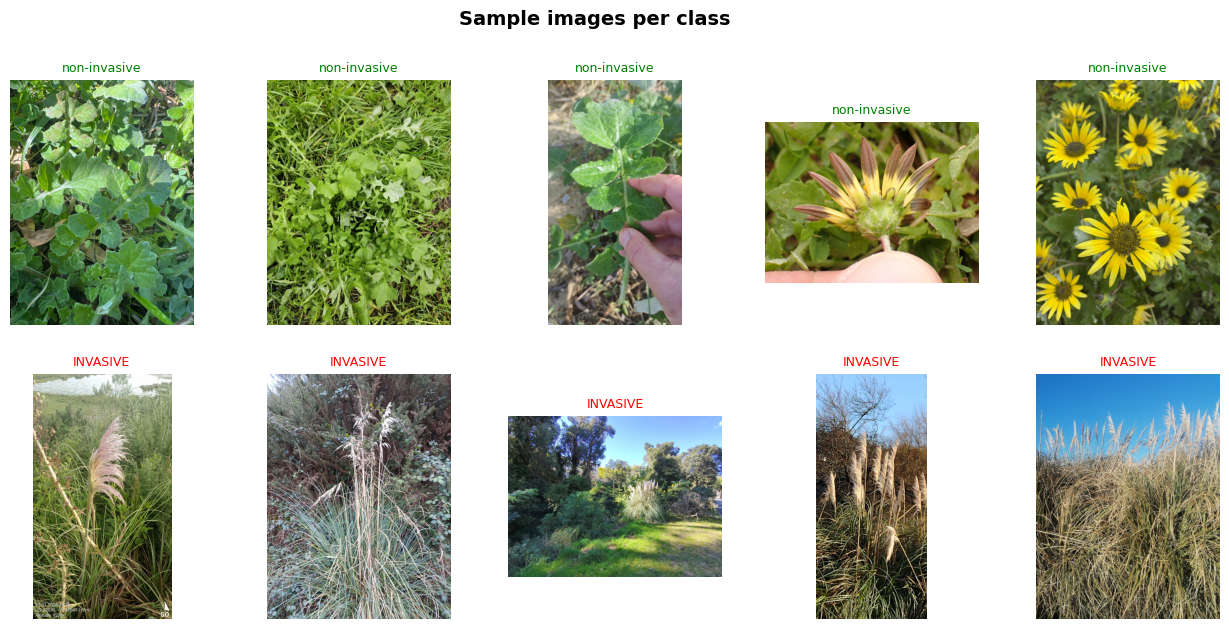

In [31]:
# ─── Visual sanity check – display a few downloaded images ───────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Sample images per class", fontsize=14, fontweight="bold")

for row, (class_name, info) in enumerate(SPECIES.items()):
    imgs = sorted((DATA_DIR / "train" / class_name).glob("*.jpg"))[:5]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        try:
            img = Image.open(img_path)
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "ERR", ha="center", va="center")
        ax.set_title(
            ("INVASIVE" if "cortaderia" in class_name else "non-invasive"),
            color="red" if "cortaderia" in class_name else "green",
            fontsize=9,
        )
        ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved sample_images.png")

In [32]:
# ─── Final summary ────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("DATASET SUMMARY")
print("="*55)
for split in ("train", "val"):
    print(f"\n  [{split.upper()}]")
    for class_name in SPECIES:
        n = len(list((DATA_DIR / split / class_name).glob("*.jpg")))
        tag = "INVASIVE" if "cortaderia" in class_name else "non-invasive"
        print(f"    {class_name:30s}  ({tag:12s})  {n:4d} images")
print("\n✓ Data collection complete. Run 02_train_classifier.ipynb next.")


DATASET SUMMARY

  [TRAIN]
    arctotheca_calendula_(l.)_levyns  (non-invasive)   238 images
    cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.  (INVASIVE    )   240 images
    tradescantia_fluminensis_vell.  (non-invasive)   239 images
    laurus_nobilis_l.               (non-invasive)   240 images
    oenothera_rosea_aiton           (non-invasive)   237 images
    non_invasive                    (non-invasive)   237 images

  [VAL]
    arctotheca_calendula_(l.)_levyns  (non-invasive)    59 images
    cortaderia_selloana_(schult._&_schult.f.)_asch._&_graebn.  (INVASIVE    )    60 images
    tradescantia_fluminensis_vell.  (non-invasive)    59 images
    laurus_nobilis_l.               (non-invasive)    60 images
    oenothera_rosea_aiton           (non-invasive)    59 images
    non_invasive                    (non-invasive)    59 images

✓ Data collection complete. Run 02_train_classifier.ipynb next.


In [ ]:
# ─── Extra non-invasive download (run after main pipeline) ─────────────────────
# Add more non-invasive species to improve class balance. Downloads in parallel (one process per species).

N_EXTRA_NON_INVASIVE_SPECIES = 20   # how many extra species to add
IMAGES_PER_EXTRA_SPECIES = 50      # images to download per extra species (~TARGET_PER_CLASS / 5)

# Get non-invasive pool, exclude already used
non_inv_pool = df_species[~df_species["is_invasive"]]
non_inv_pool = non_inv_pool[non_inv_pool["scientificName"].apply(to_folder_name) != "miscanthus_sinensis"]
already_used = set(to_folder_name(row["scientificName"]) for _, row in non_inv_sample.iterrows())
non_inv_pool = non_inv_pool[~non_inv_pool["scientificName"].apply(to_folder_name).isin(already_used)]

extra_sample = non_inv_pool.sample(n=min(N_EXTRA_NON_INVASIVE_SPECIES, len(non_inv_pool)), random_state=SEED + 1)
extra_species = []  # (class_name, taxon_key)
for _, row in extra_sample.iterrows():
    sci = row["scientificName"]
    fn = to_folder_name(sci)
    taxon_key = row.get("speciesKey")
    if pd.isna(taxon_key) or taxon_key == "":
        taxon_key = gbif_species_match(sci)
    if taxon_key is not None and not (isinstance(taxon_key, float) and pd.isna(taxon_key)):
        extra_species.append((f"non_invasive_extra_{fn}", int(taxon_key)))
        print(f"  + {sci} (taxonKey={taxon_key})")

if not extra_species:
    print("No extra non-invasive species to add.")
elif "non_invasive" not in SPECIES:
    print("non_invasive not in SPECIES – run config cell first.")
else:
    config = {
        "gbif_page_size": GBIF_PAGE_SIZE,
        "request_delay": REQUEST_DELAY,
        "timeout": TIMEOUT,
        "min_side_px": MIN_SIDE_PX,
        "max_aspect": MAX_ASPECT,
        "sharpness_min": SHARPNESS_MIN,
    }

    with Manager() as manager:
        progress_dict = manager.dict()
        tasks = [
            (class_name, taxon_key, IMAGES_PER_EXTRA_SPECIES, str(DATA_DIR), config, progress_dict)
            for class_name, taxon_key in extra_species
        ]

        def _print_progress():
            import threading
            stop = threading.Event()
            def _loop():
                while not stop.is_set():
                    if progress_dict:
                        lines = [f"{k}: {v}/{IMAGES_PER_EXTRA_SPECIES}" for k, v in sorted(progress_dict.items())]
                        print("\r  " + " | ".join(lines), end="", flush=True)
                    stop.wait(2)
            t = threading.Thread(target=_loop, daemon=True)
            t.start()
            return stop

        with ProcessPoolExecutor(max_workers=len(extra_species)) as executor:
            stop_p = _print_progress()
            futures = {executor.submit(download_species_worker, t): t[0] for t in tasks}
            for future in as_completed(futures):
                class_name, out_dir, downloaded, rejected = future.result()
                print(f"\n  {class_name}: ✓ {downloaded} saved | ✗ {sum(rejected.values())} rejected")
            stop_p.set()

    # Merge extra folders into non_invasive
    non_inv_raw = DATA_DIR / "raw" / "non_invasive"
    existing = sorted(non_inv_raw.glob("*.jpg"))
    next_idx = max((int(p.stem) for p in existing), default=-1) + 1
    merged = 0
    for class_name, _ in extra_species:
        src_dir = DATA_DIR / "raw" / class_name
        if src_dir.exists():
            for f in sorted(src_dir.glob("*.jpg")):
                shutil.copy2(f, non_inv_raw / f"{next_idx:05d}.jpg")
                next_idx += 1
                merged += 1
            shutil.rmtree(src_dir)
    print(f"\n✓ Merged {merged} images into non_invasive (total: {len(list(non_inv_raw.glob('*.jpg')))}).")
    print("  Re-run the train/val split cell to update data/train and data/val.")